In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime

movies = pd.read_csv('movies.csv')

#print(movies.head())
#print(movies.shape)
#print(movies.isna().sum())
#print(movies.info())
#print(movies['genres'].describe())
#print(movies['genres'].nunique())


In [4]:
ratings = pd.read_csv('ratings.csv')

#print(ratings.head())
#print(ratings.shape)
#print(ratings.isna().sum())
#print(ratings.info())
#pd.to_datetime(1112486027, unit='s')
#print(ratings['rating'].describe())
#print(pd.to_datetime(ratings['timestamp'].min(), unit='s'))
#print(pd.to_datetime(ratings['timestamp'].max(), unit='s'))

In [4]:
links = pd.read_csv('links.csv')
print(links.head())
#print(links.shape)
#print(links.isna().sum())
#print(links.info())
#print(links[links['tmdbId'].isna()])

   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0


In [1]:
#tags = pd.read_csv('tags.csv')
#print(tags.head())
#print(tags.shape)
#print(tags.info())
#print(tags.isna().sum())
#print(tags[tags['tag'].isna()])
#print(tags['tag'].describe())

In [7]:
genome_scores = pd.read_csv('genome-scores.csv')
#print(genome_scores.head(10))
#print(genome_scores.shape)
#print(genome_scores.info())
#print(genome_scores.isna().sum())
#print(genome_scores['relevance'].describe())

In [8]:
genome_tags = pd.read_csv('genome-tags.csv')
#print(genome_tags.head())
#print(genome_tags.shape)
#print(genome_tags.info())
#print(genome_tags.isna().sum())

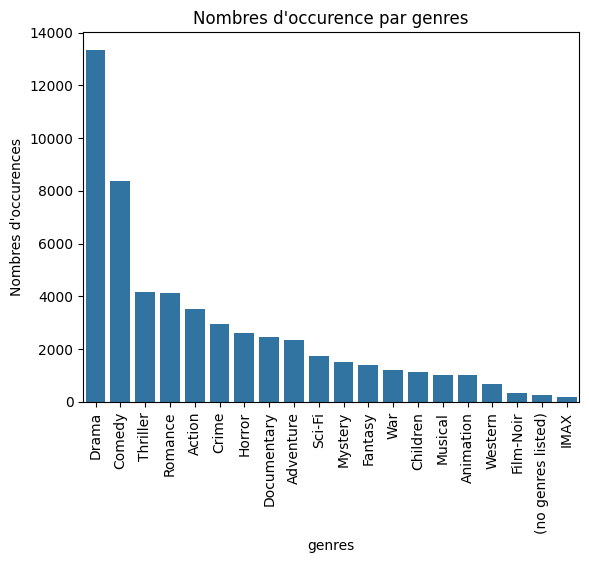

On peut constater que 24.526706613241185 % est uniquement liée a la categorie Drama


In [9]:
genrecount = movies['genres'].str.split('|').explode().value_counts()
sns.barplot(x=genrecount.index, y=genrecount.values)
plt.xticks(rotation=90)
plt.ylabel("Nombres d'occurences")
plt.title("Nombres d'occurence par genres")
plt.show()

# On constate que Drama et Comedy dominent largemnet le catalogue , ce qui peut biaiser le systement de recommandation
# On pourrait se voir recommander du drama meme si nous n'en voulons pas 

print('On peut constater que', genrecount['Drama'] / genrecount.sum() *100, '%', 'est uniquement liée a la categorie', genrecount.idxmax())



#Occurance/genre + occurance/genre.mean 

#Lien entre les genres ? 
#BEAUCOUP DE GENRE 
#Film multi genre 

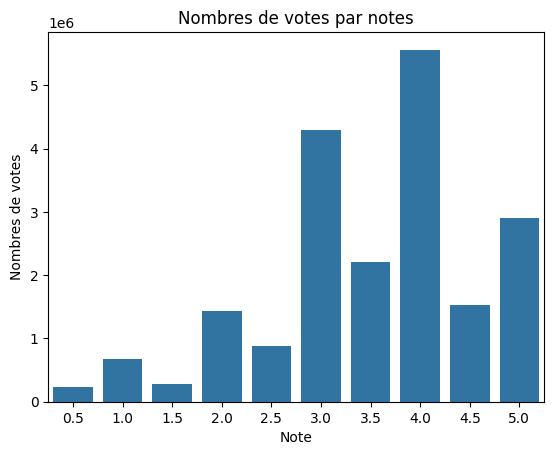

On peut retrouver : 82.43271100985022 % de notes entre 3 et 5


In [10]:
sns.barplot(ratings['rating'].value_counts())
plt.title('Nombres de votes par notes')
plt.ylabel('Nombres de votes')
plt.xlabel('Note')
plt.show()

#On peut clairement distinguer que la majorité des votes est entre 3 et 5 , ce qui peut biaiser le resultat car on peut supposer que les gens notent en majorité les films aimé
#Ce sera plus compliquer de differencier réelement une echelle de 3 a 5 que de 1 a 5


notesup = ratings[ratings['rating'] >= 3]
print('On peut retrouver :', len(notesup)/len(ratings)*100, '%', 'de notes entre 3 et 5')


   userId  movieId            tag   timestamp
0      18     4141    Mark Waters  1240597180
1      65      208      dark hero  1368150078
2      65      353      dark hero  1368150079
3      65      521  noir thriller  1368149983
4      65      592      dark hero  1368150078


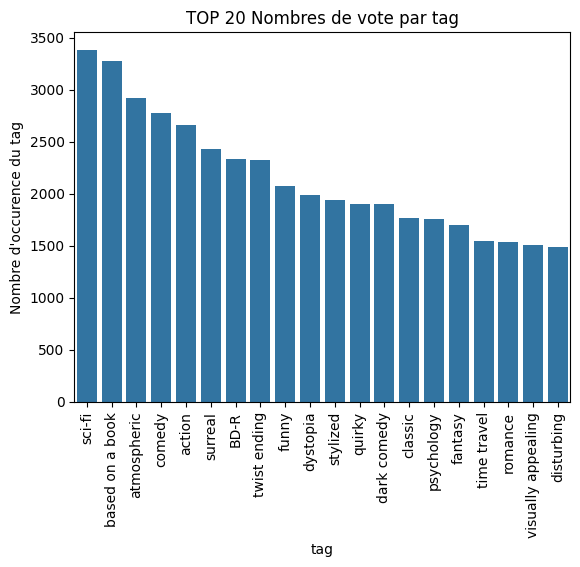

In [11]:
print(tags.head())
tag20 = tags['tag'].value_counts().head(20)
sns.barplot(tag20)
plt.ylabel("Nombre d'occurence du tag")
plt.title('TOP 20 Nombres de vote par tag')
plt.xticks(rotation=90)
plt.show()


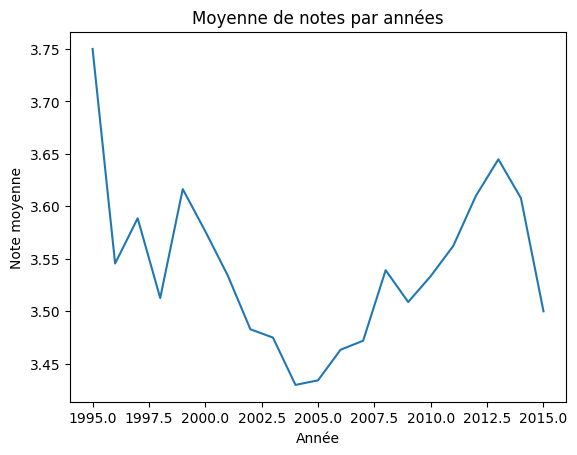

year
1995          4
1996    1612609
1997     700982
1998     308070
1999    1198384
2000    1953659
2001    1186125
2002     869719
2003    1035878
2004    1170049
2005    1803158
2006    1171836
2007    1053430
2008    1158777
2009     930036
2010     903691
2011     766366
2012     731389
2013     599327
2014     562888
2015     283886
Name: rating, dtype: int64

In [12]:
ratings['year'] = pd.to_datetime(ratings['timestamp'], unit='s').dt.year

noteyear = ratings.groupby('year')['rating'].mean()
plt.plot(noteyear.index, noteyear.values)
plt.xlabel('Année')
plt.ylabel('Note moyenne')
plt.title('Moyenne de notes par années')
plt.show()


#La note moyenne reste stable entre 3.4 et 3.7 sur 20 ans — la variable année n'apporte pas d'avantage pour notre système de recommandation. 
#Les données de 1995 sont peu fiables car le nombre de notes est trop faible.
ratings.groupby('year')['rating'].count()